# EDA

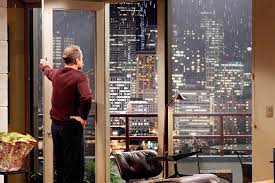

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
df = pd.read_csv("data/eda.csv")

In [3]:
df.head()

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.000,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2014-12-09,538000.000,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,2015-02-25,180000.000,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2014-12-09,604000.000,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,2015-02-18,510000.000,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [4]:
df.shape

(21597, 21)

In [5]:
# Understand the Data
df.describe()

,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,540296.574,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284
std,367368.140,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442
min,78000.000,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,322000.000,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,450000.000,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,645000.000,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,7700000.000,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000


In [6]:
# Clean up Data
df["date"] = pd.to_datetime(df["date"])

In [7]:
# Why? "September" is easier to analyze than 2015-09-21
df["sale_month"] = df["date"].dt.month_name()
df["house_age"] = df["date"].dt.year - df["yr_built"]

In [8]:
# Check missing values
df.isnull().sum()

date                0
price               0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
sale_month          0
house_age           0
dtype: int64

In [9]:
df.head()

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_month,house_age
0,2014-10-13,221900.000,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,October,59
1,2014-12-09,538000.000,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,December,63
2,2015-02-25,180000.000,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,February,82
3,2014-12-09,604000.000,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,December,49
4,2015-02-18,510000.000,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,February,28


In [10]:
# check the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21597 non-null  datetime64[us]
 1   price          21597 non-null  float64       
 2   id             21597 non-null  int64         
 3   bedrooms       21597 non-null  float64       
 4   bathrooms      21597 non-null  float64       
 5   sqft_living    21597 non-null  float64       
 6   sqft_lot       21597 non-null  float64       
 7   floors         21597 non-null  float64       
 8   waterfront     19206 non-null  float64       
 9   view           21534 non-null  float64       
 10  condition      21597 non-null  int64         
 11  grade          21597 non-null  int64         
 12  sqft_above     21597 non-null  float64       
 13  sqft_basement  21145 non-null  float64       
 14  yr_built       21597 non-null  int64         
 15  yr_renovated   17749 non-null 

In [11]:
# find missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
dtype: int64

In [12]:
df.columns = df.columns.str.strip()

In [13]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Reset everything
plt.style.use("default")
mpl.rcdefaults()
sns.reset_defaults()

# Force text to be visible
mpl.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "font.size": 12
})

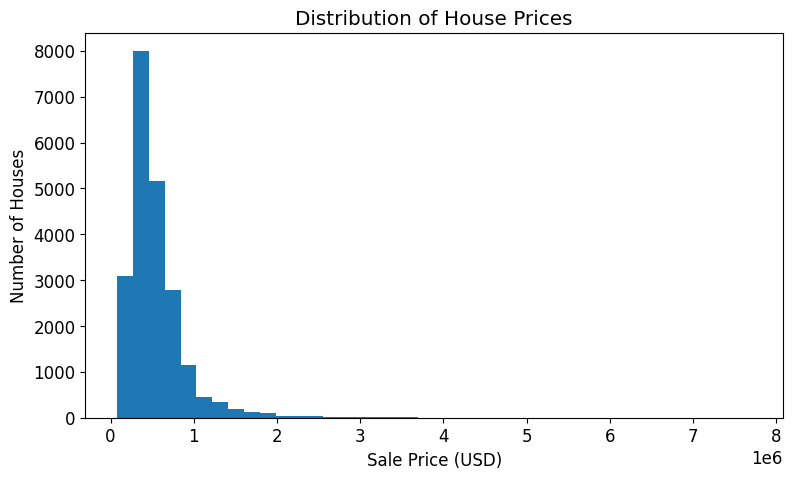

In [14]:
# Explore the price

plt.figure(figsize=(9,5))

plt.hist(df["price"], bins=40)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price (USD)")
plt.ylabel("Number of Houses")

plt.show()

The distribution is right-skewed, with most houses selling below the highest prices.

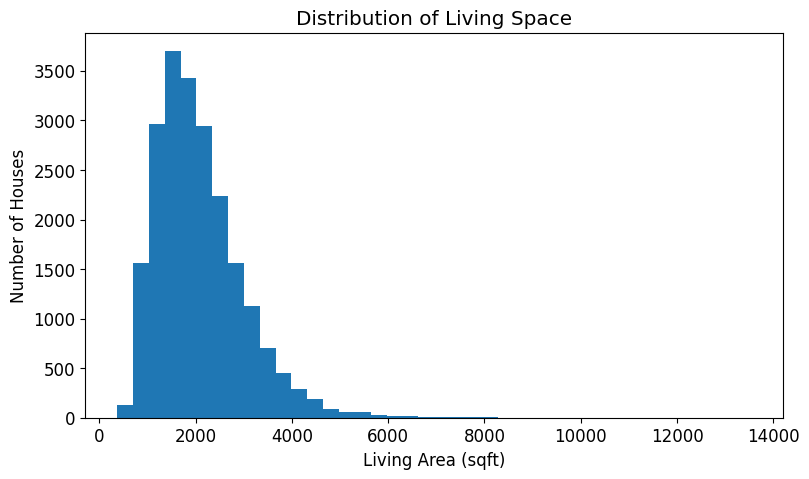

In [15]:
# Explore the living space
plt.figure(figsize=(9,5))

plt.hist(df["sqft_living"], bins=40)

plt.title("Distribution of Living Space")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Number of Houses")

plt.show()

Most homes fall within a moderate range of living space, with relatively few very large homes.

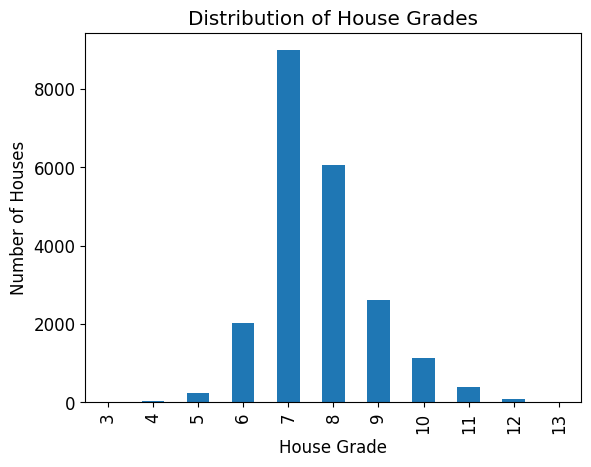

In [16]:
# Explore Grade
ax = df["grade"].value_counts().sort_index().plot(kind="bar")

ax.set_title("Distribution of House Grades")
ax.set_xlabel("House Grade")
ax.set_ylabel("Number of Houses")

plt.show()

Mid-range house grades are the most common in the dataset.

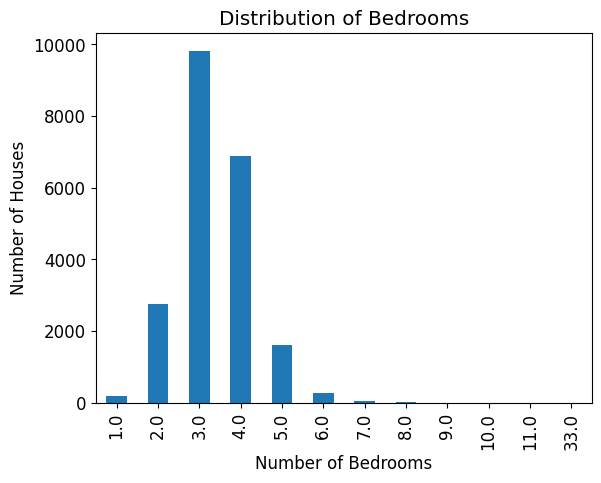

In [17]:
ax = df["bedrooms"].value_counts().sort_index().plot(kind="bar")

ax.set_title("Distribution of Bedrooms")
ax.set_xlabel("Number of Bedrooms")
ax.set_ylabel("Number of Houses")

plt.show()

In [18]:
# Clean the data
df["date"] = pd.to_datetime(df["date"])

In [19]:
# Create helper columns
df["sale_month"] = df["date"].dt.month
df["sale_month_name"] = df["date"].dt.month_name()
df["house_age"] = df["date"].dt.year - df["yr_built"]
df["renovated"] = df["yr_renovated"] > 0

In [20]:
# Calculate House Age, create column for it
df["house_age"] = df["date"].dt.year - df["yr_built"]

In [21]:
# Identify which houses have been renovated (Instead of repeatedly asking,'Was this renovated?'you create a simple True/False answer)
df["renovated"] = df["yr_renovated"] > 0

Testing Hypotheses

Hypothesis 1

Renovated homes sell for higher prices.

In [22]:
df.groupby("renovated")["price"].mean()

renovated
False   532140.320
True    768901.892
Name: price, dtype: float64

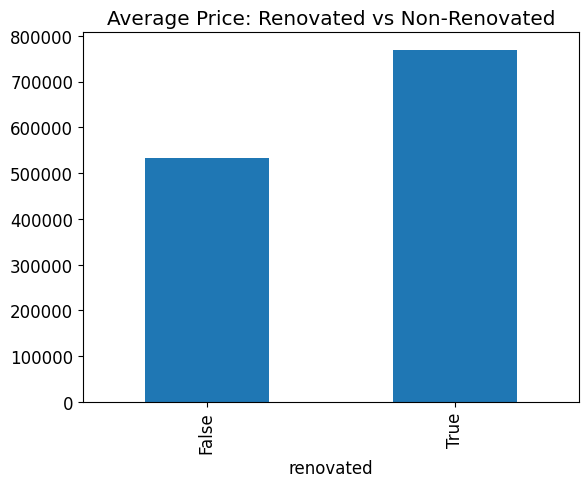

In [23]:
df.groupby("renovated")["price"].mean().plot(kind="bar")
plt.title("Average Price: Renovated vs Non-Renovated")
plt.show()

Hypothesis 2

Premium ZIP codes have higher prices.

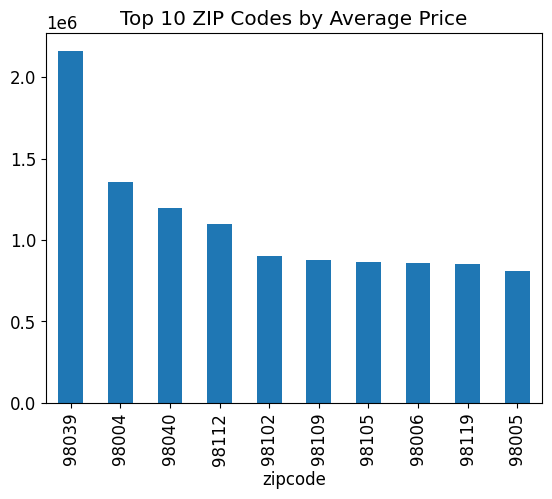

In [24]:
zip_prices = (
    df.groupby("zipcode")["price"]
      .mean()
      .sort_values(ascending=False)
)
zip_prices.head(10).plot(kind="bar")
plt.title("Top 10 ZIP Codes by Average Price")
plt.show()

ZIP 98039 stands out as the highest-priced area.

Hypothesis 3

Spring achieves higher prices.

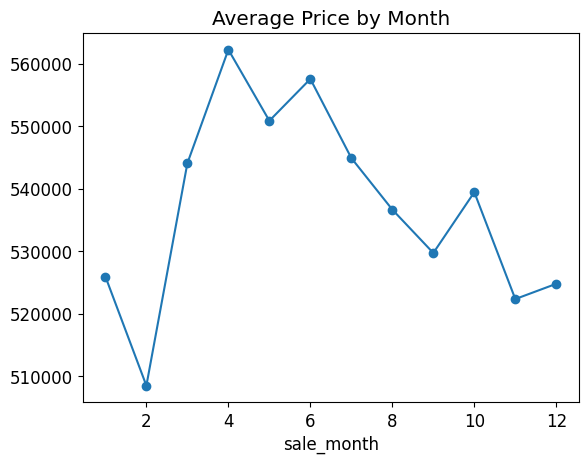

In [25]:
monthly = df.groupby("sale_month")["price"].mean()

monthly.plot(marker="o")
plt.title("Average Price by Month")
plt.show()

Prices appear to peak during spring.